<a href="https://colab.research.google.com/github/OgunbanjoT/medical-cost-classification/blob/main/AI_Assignment8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step A: Load and Preprocess the Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
# 1. Load dataset directly via raw downloadable link
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

In [3]:
# 2. Data Cleaning
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

In [4]:
# 3. Create a binary classification target based on continuous charges
# (High Cost = 1 if charges > median, else Low Cost = 0)
median_charge = df['charges'].median()
df['cost_class'] = np.where(df['charges'] > median_charge, 1, 0)
# Drop the original continuous feature to prevent data leakage
df = df.drop(columns=['charges'])

In [6]:
# 4. Convert Categorical Data using Label Encoding
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

# 5. Split Dataset into Training and Testing Sets
X = df.drop(columns=['cost_class'])
y = df['cost_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for algorithms sensitive to variance (like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Completed successfully! Training shape:", X_train.shape)

Data Preprocessing Completed successfully! Training shape: (1069, 6)


Step B: Exploratory Data Analysis (EDA) Visualizations

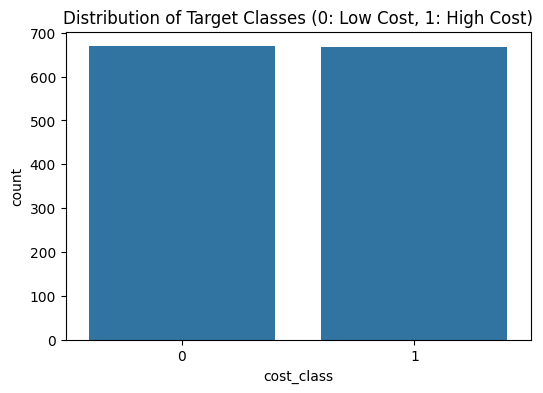

In [7]:
# 1. Distribution of Classes
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Distribution of Target Classes (0: Low Cost, 1: High Cost)')
plt.show()

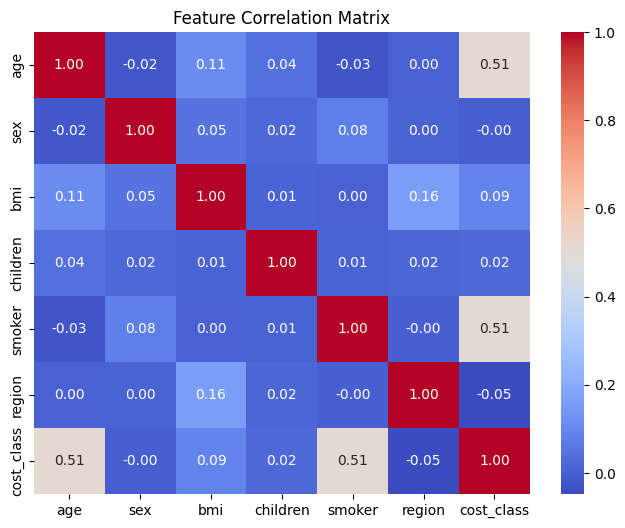

In [8]:
# 2. Correlation Matrix Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

Step C: Model Training & Evaluation

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Initialize two classification models requested by assignment
model1 = LogisticRegression(random_state=42)
model2 = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train models
model1.fit(X_train_scaled, y_train)
model2.fit(X_train, y_train) # Trees don't strictly require scaling

# Evaluate Function
def evaluate_model(model, X_tst, y_tst, is_scaled=False):
    preds = model.predict(X_tst)
    probs = model.predict_proba(X_tst)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_tst, preds),
        "Precision": precision_score(y_tst, preds),
        "Recall": recall_score(y_tst, preds),
        "F1-Score": f1_score(y_tst, preds)
    }
    return preds, probs, metrics

preds1, probs1, metrics1 = evaluate_model(model1, X_test_scaled, y_test)
preds2, probs2, metrics2 = evaluate_model(model2, X_test, y_test)

print("Logistic Regression Metrics:", metrics1)
print("Decision Tree Metrics:", metrics2)

Logistic Regression Metrics: {'Accuracy': 0.9067164179104478, 'Precision': 0.8881118881118881, 'Recall': 0.9338235294117647, 'F1-Score': 0.910394265232975}
Decision Tree Metrics: {'Accuracy': 0.9291044776119403, 'Precision': 0.968, 'Recall': 0.8897058823529411, 'F1-Score': 0.9272030651340997}


Step D: Confusion Matrices & ROC Curves

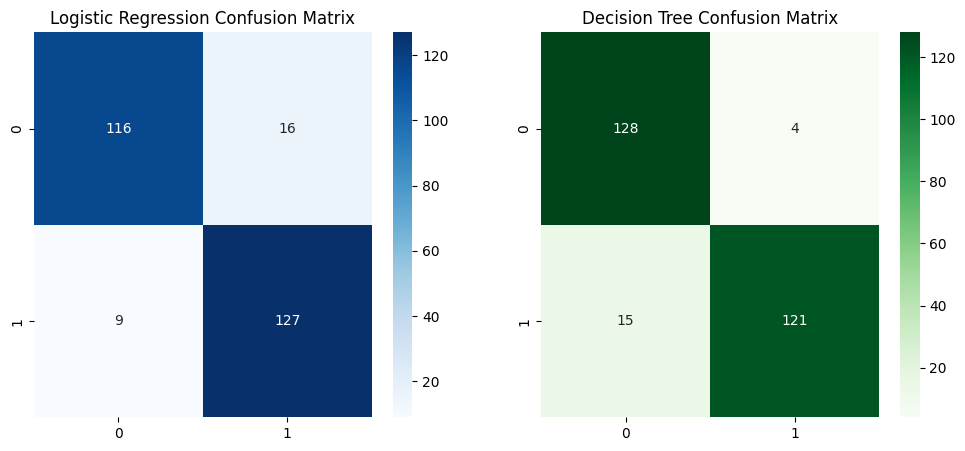

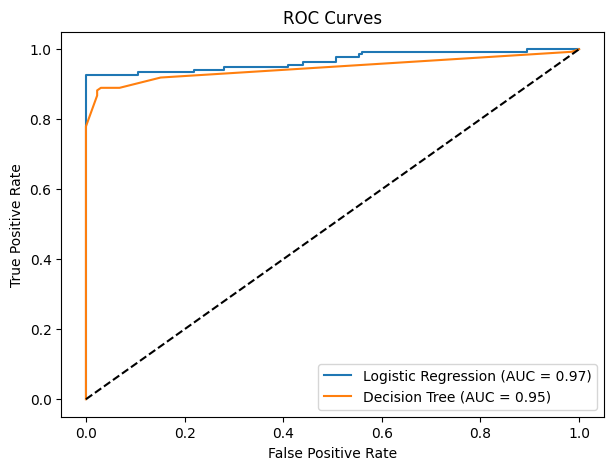

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix Logistic Regression
sns.heatmap(confusion_matrix(y_test, preds1), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression Confusion Matrix')

# Confusion Matrix Decision Tree
sns.heatmap(confusion_matrix(y_test, preds2), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('Decision Tree Confusion Matrix')
plt.show()

# ROC Curve Plotting
fpr1, tpr1, _ = roc_curve(y_test, probs1)
fpr2, tpr2, _ = roc_curve(y_test, probs2)

plt.figure(figsize=(7,5))
plt.plot(fpr1, tpr1, label=f'Logistic Regression (AUC = {auc(fpr1, tpr1):.2f})')
plt.plot(fpr2, tpr2, label=f'Decision Tree (AUC = {auc(fpr2, tpr2):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()